# Topography vs. Optimized Traits Correlation Analysis

## Enhanced Analysis with Elevation, Slope, and Aspect

This notebook addresses reviewer comment L704-706:

> "This indicates that external factors such as microclimate conditions, soil nutrition, water availability, plant age or health, and even uncertainties in the PFT classification map could be influencing traits within these groups."

**Objective**: Calculate correlations between topographic variables and the three optimized traits:

### Topographic Variables:
1. **Elevation (DSM)** - Proxy for temperature, water availability
2. **Slope** - Affects water drainage, soil depth, erosion
3. **Aspect** - Controls solar exposure and microclimate

### Plant Traits:
- Chlorophyll content (Chl)
- Leaf Mass per Area (LMA)
- Leaf Water Content (LWC)

This comprehensive analysis tests whether **topography** explains observed within-PFT trait variability.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import rioxarray
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

print("✓ Packages imported successfully")

✓ Packages imported successfully


## 1. Load Optimized Trait Data

Load the fitted traits (chlorophyll, LMA, LWC) from the optimization results and calculate time-averaged values.

In [2]:
# Define paths
base_path = Path('/home/renatob/data/FluoData1/aviris_dangermond')
elev_dir = Path('/home/renatob/data/FluoData1/aviris_dangermond/elevation')
trait_path = base_path / 'traits' / 'datasets' / 'clima_fit_prescribed_lai_ci'

# Load trait maps (same inputs used in Figure 5)
chl_ds = xr.open_dataset(trait_path / 'chl_aviris_dangermond_clima_fit_reg.nc')
lma_ds = xr.open_dataset(trait_path / 'lma_aviris_dangermond_clima_fit_reg.nc')
lwc_ds = xr.open_dataset(trait_path / 'lwc_aviris_dangermond_clima_fit_reg.nc')

print('Trait datasets loaded:')
print('  CHL vars:', list(chl_ds.data_vars))
print('  LMA vars:', list(lma_ds.data_vars))
print('  LWC vars:', list(lwc_ds.data_vars))
print(f"Lat/Lon shape: {len(chl_ds.lat)} x {len(chl_ds.lon)}")


Trait datasets loaded:
  CHL vars: ['crs', 'chl']
  LMA vars: ['crs', 'lma']
  LWC vars: ['crs', 'lwc']
Lat/Lon shape: 458 x 492


In [3]:
# Calculate time-averaged traits (units aligned with Figure 5)
print('Calculating time-averaged traits...')
chl_mean = chl_ds['chl'].mean(dim='time')  # µg/cm²
lma_mean = lma_ds['lma'].mean(dim='time') * 1e4  # g/cm² -> g/m²
# LWC in mol/m², convert to g/cm²: mol/m² * 18 / 10000
lwc_mean = lwc_ds['lwc'].mean(dim='time') * 0.0018

print('\nTime-averaged trait statistics:')
print(f"  Chlorophyll: min={float(chl_mean.min()):.3f}, max={float(chl_mean.max()):.3f}, mean={float(chl_mean.mean()):.3f} µg/cm²")
print(f"  LMA:         min={float(lma_mean.min()):.3f}, max={float(lma_mean.max()):.3f}, mean={float(lma_mean.mean()):.3f} g/m²")
print(f"  LWC:         min={float(lwc_mean.min()):.3f}, max={float(lwc_mean.max()):.3f}, mean={float(lwc_mean.mean()):.3f} g/cm²")
print('\n✓ Trait data ready for analysis')


Calculating time-averaged traits...

Time-averaged trait statistics:
  Chlorophyll: min=0.051, max=80.000, mean=33.813 µg/cm²
  LMA:         min=7.000, max=498.000, mean=63.056 g/m²
  LWC:         min=0.000, max=0.036, mean=0.004 g/cm²

✓ Trait data ready for analysis


## 2. Load Topographic Data

Load elevation (DSM), slope, and aspect layers from OpenTopography.

### Expected Files (from OpenTopography download):
- **Elevation**: DSM GeoTIFF (e.g., `output_DSM.tif`)
- **Slope**: Slope GeoTIFF (e.g., `output_slope.tif`)
- **Aspect**: Aspect GeoTIFF (e.g., `output_aspect.tif`)

Update filenames below to match your downloads.

In [4]:
# Absolute paths to OpenTopography layers
topo_files = {
    'elevation': Path('/home/renatob/data/FluoData1/aviris_dangermond/elevation/output_DSM.tif'),
    'slope': Path('/home/renatob/data/FluoData1/aviris_dangermond/elevation/output_slope.tif'),
    'aspect': Path('/home/renatob/data/FluoData1/aviris_dangermond/elevation/output_aspect.tif')
}

# Load topographic data
topo_data = {}
missing_files = []

for var_name, filepath in topo_files.items():
    filepath = Path(filepath)
    if filepath.exists():
        print(f"Loading {var_name} from {filepath}...")
        ds = rioxarray.open_rasterio(filepath, masked=True)
        topo_data[var_name] = ds.squeeze()  # Remove band dimension

        data = ds.squeeze().values
        valid_data = data[(data != -32768) & (data != -9999) & ~np.isnan(data) & ~np.isinf(data)]

        if len(valid_data) > 0:
            data_min = float(np.min(valid_data))
            data_max = float(np.max(valid_data))
            data_mean = float(np.mean(valid_data))
            n_valid = len(valid_data)
            n_total = data.size
            pct_valid = 100 * n_valid / n_total

            if var_name == 'elevation':
                print(f"  ✓ Range: {data_min:.1f} to {data_max:.1f} m (mean: {data_mean:.1f} m)")
            elif var_name == 'slope':
                print(f"  ✓ Range: {data_min:.1f}° to {data_max:.1f}° (mean: {data_mean:.1f}°)")
            elif var_name == 'aspect':
                print(f"  ✓ Range: {data_min:.1f}° to {data_max:.1f}° (mean: {data_mean:.1f}°)")

            print(f"    Valid pixels: {n_valid:,} / {n_total:,} ({pct_valid:.1f}%)")
        else:
            print(f"  ⚠️  Warning: No valid data found (all NoData values)")
    else:
        missing_files.append(str(filepath))
        print(f"  ⚠️  {var_name} file not found: {filepath}")

if missing_files:
    print(f"⚠️  Missing {len(missing_files)} file(s). Please download from OpenTopography.")
    print('   See README.md for download instructions.')
else:
    print(f"✓ All {len(topo_data)} topographic layers loaded successfully!")


Loading elevation from /home/renatob/data/FluoData1/aviris_dangermond/elevation/output_DSM.tif...
  ✓ Range: 0.0 to 528.0 m (mean: 227.8 m)
    Valid pixels: 24,742,195 / 55,903,042 (44.3%)
Loading slope from /home/renatob/data/FluoData1/aviris_dangermond/elevation/output_slope.tif...
  ✓ Range: 0.0° to 89.1° (mean: 25.5°)
    Valid pixels: 24,711,263 / 55,903,042 (44.2%)
Loading aspect from /home/renatob/data/FluoData1/aviris_dangermond/elevation/output_aspect.tif...
  ✓ Range: 0.0° to 359.8° (mean: 184.1°)
    Valid pixels: 22,494,232 / 55,903,042 (40.2%)
✓ All 3 topographic layers loaded successfully!


## 3. Regrid Topography to Match Trait Grid

Interpolate topographic data to the same grid as the trait data for pixel-wise correlation.

In [5]:
# Ensure topo_data is defined
topo_data = topo_data if 'topo_data' in locals() else {}

if topo_data:
    print("Regridding topographic data to match trait grid...")
    print(f"  Target grid: {len(chl_mean.lat)} x {len(chl_mean.lon)} pixels")
    
    # Print trait coordinate info for verification
    print(f"\nTrait coordinate ordering:")
    print(f"  lat[0] = {float(chl_mean.lat[0]):.6f} (south/min)")
    print(f"  lat[-1] = {float(chl_mean.lat[-1]):.6f} (north/max)")
    print(f"  lon[0] = {float(chl_mean.lon[0]):.6f} (should be west/min)")
    print(f"  lon[-1] = {float(chl_mean.lon[-1]):.6f} (should be east/max)")
    
    topo_regridded = {}
    
    for var_name, data in topo_data.items():
        print(f"\n  Processing {var_name}...")
        
        # Mask NoData values (-32768 for DEM, -9999 for slope/aspect)
        if data.rio.nodata is not None:
            data_masked = data.where(data != data.rio.nodata)
        else:
            data_masked = data
        
        # Also mask common NoData values
        data_masked = data_masked.where(data_masked != -9999)
        data_masked = data_masked.where(data_masked != -32768)
        
        print(f"    Original CRS: {data_masked.rio.crs}")
        print(f"    Original shape: {data_masked.shape}")
        
        # Reproject from UTM to WGS84 to match trait data
        data_wgs84 = data_masked.rio.reproject("EPSG:4326")
        print(f"    Reprojected to WGS84")
        
        # Check coordinate names and ordering after reprojection
        x_coord = 'x' if 'x' in data_wgs84.dims else 'lon'
        y_coord = 'y' if 'y' in data_wgs84.dims else 'lat'
        
        print(f"    Reprojected coords: {x_coord}[0]={float(data_wgs84[x_coord][0]):.6f}, "
              f"{y_coord}[0]={float(data_wgs84[y_coord][0]):.6f}")
        
        # CRITICAL: Interpolate using trait's exact lat/lon arrays (including their ordering!)
        # This ensures pixel-to-pixel alignment for correlation analysis
        regridded = data_wgs84.interp(
            {x_coord: chl_mean.lon,   # Trait's lon array (west→east, increasing)
             y_coord: chl_mean.lat},  # Trait's lat array (south→north, increasing)
            method='linear'
        )
        
        # Align dimension names and order with trait arrays (lon, lat)
        if x_coord != 'lon' and 'lon' not in regridded.dims:
            regridded = regridded.rename({x_coord: 'lon'})
        if y_coord != 'lat' and 'lat' not in regridded.dims:
            regridded = regridded.rename({y_coord: 'lat'})
        # Ensure consistent dimension order
        if 'lat' in regridded.dims and 'lon' in regridded.dims:
            regridded = regridded.transpose('lat', 'lon')
        elif 'y' in regridded.dims and 'x' in regridded.dims:
            regridded = regridded.rename({'x': 'lon', 'y': 'lat'}).transpose('lat', 'lon')
        
        print(f"    Regridded coords: lon[0]={float(regridded.lon[0]):.6f}, "
              f"lat[0]={float(regridded.lat[0]):.6f}")
        print(f"    Regridded shape: {regridded.shape}")
        
        # VERIFICATION: Check that coordinates match trait data exactly
        lon_match = np.allclose(regridded.lon.values, chl_mean.lon.values)
        lat_match = np.allclose(regridded.lat.values, chl_mean.lat.values)
        
        if lon_match and lat_match:
            print(f"    ✓ Coordinates match trait data exactly!")
        else:
            print(f"    ⚠️  WARNING: Coordinates don't match!")
            print(f"       lon_match: {lon_match}, lat_match: {lat_match}")
        
        topo_regridded[var_name] = regridded
        valid_pixels = (~np.isnan(regridded.values)).sum()
        print(f"    Valid pixels: {valid_pixels:,}")
    
    print("\n✓ Regridding complete!")
    print("\n" + "="*80)
    print("VERIFICATION: All topography layers should now have:")
    print(f"  - Same shape as traits: {chl_mean.shape}")
    print(f"  - Same lat ordering: south→north (increasing)")
    print(f"  - Same lon ordering: west→east (increasing)")
    print(f"  - Pixel [i,j] in topography aligns with pixel [i,j] in traits")
    print("="*80)
else:
    print("⚠️  No topographic data loaded. Please add GeoTIFF files and re-run.")


Regridding topographic data to match trait grid...
  Target grid: 458 x 492 pixels

Trait coordinate ordering:
  lat[0] = 34.441330 (south/min)
  lat[-1] = 34.577595 (north/max)
  lon[0] = -120.501933 (should be west/min)
  lon[-1] = -120.355531 (should be east/max)

  Processing elevation...
    Original CRS: EPSG:32611
    Original shape: (7993, 6994)
    Reprojected to WGS84
    Reprojected coords: x[0]=-120.510041, y[0]=34.583665
    Regridded coords: lon[0]=-120.501933, lat[0]=34.441330
    Regridded shape: (458, 492)
    ✓ Coordinates match trait data exactly!
    Valid pixels: 109,800

  Processing slope...
    Original CRS: EPSG:32611
    Original shape: (7993, 6994)
    Reprojected to WGS84
    Reprojected coords: x[0]=-120.510041, y[0]=34.583665
    Regridded coords: lon[0]=-120.501933, lat[0]=34.441330
    Regridded shape: (458, 492)
    ✓ Coordinates match trait data exactly!
    Valid pixels: 109,649

  Processing aspect...
    Original CRS: EPSG:32611
    Original shape: 

## 4. Calculate Correlations

Calculate Pearson and Spearman correlations between each topographic variable and each trait.

In [6]:
def calculate_correlations(topo_var, trait, topo_name, trait_name):
    """
    Calculate correlation between a topographic variable and a trait.
    
    Parameters:
    -----------
    topo_var : xarray.DataArray
        Topographic variable (elevation, slope, or aspect)
    trait : xarray.DataArray
        Trait data (chl, lma, or lwc)
    topo_name : str
        Name of topographic variable
    trait_name : str
        Name of trait
    
    Returns:
    --------
    tuple: (results_dict, topo_valid, trait_valid)
    """
    # Flatten arrays
    topo_flat = topo_var.values.flatten()
    trait_flat = trait.values.flatten()
    
    # Create comprehensive mask for valid data
    # Filter out: NaN, inf, -inf, and extreme values (NoData markers)
    valid_mask = (
        ~np.isnan(topo_flat) & ~np.isnan(trait_flat) &
        ~np.isinf(topo_flat) & ~np.isinf(trait_flat) &
        (topo_flat != -9999) & (topo_flat != -32768) &
        (trait_flat > 0) &  # Traits should be positive
        (topo_flat < 1e10)  # Filter absurdly large values
    )
    
    topo_valid = topo_flat[valid_mask]
    trait_valid = trait_flat[valid_mask]
    
    # Additional sanity check
    if len(topo_valid) < 100:
        print(f"  WARNING: Only {len(topo_valid)} valid pixels for {topo_name} vs {trait_name}")
        return None, None, None
    
    # Calculate correlations
    pearson_r, pearson_p = stats.pearsonr(topo_valid, trait_valid)
    spearman_r, spearman_p = stats.spearmanr(topo_valid, trait_valid)
    
    # Calculate R²
    r_squared = pearson_r ** 2
    
    results = {
        'topo_variable': topo_name,
        'trait': trait_name,
        'n_pixels': len(topo_valid),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'r_squared': r_squared,
        'topo_mean': np.mean(topo_valid),
        'topo_std': np.std(topo_valid),
        'topo_min': np.min(topo_valid),
        'topo_max': np.max(topo_valid),
        'trait_mean': np.mean(trait_valid),
        'trait_std': np.std(trait_valid)
    }
    
    return results, topo_valid, trait_valid

print("✓ Correlation function defined")

✓ Correlation function defined


In [7]:
if topo_regridded:
    print("Calculating correlations for all topography-trait combinations...\n")
    
    # Define trait data and names
    traits = {
        'Chlorophyll': chl_mean,
        'LMA': lma_mean,
        'LWC': lwc_mean
    }
    
    # Store all results
    all_results = []
    correlation_data = {}  # For plotting
    
    # Calculate correlations for each combination
    for topo_name, topo_var in topo_regridded.items():
        correlation_data[topo_name] = {}
        
        for trait_name, trait_var in traits.items():
            results, topo_vals, trait_vals = calculate_correlations(
                topo_var, trait_var, topo_name.capitalize(), trait_name
            )
            
            # Skip if no valid data
            if results is None:
                continue
                
            all_results.append(results)
            correlation_data[topo_name][trait_name] = (topo_vals, trait_vals, results)
            
            # Print summary with data range
            sig = "***" if results['pearson_p'] < 0.001 else "**" if results['pearson_p'] < 0.01 else "*" if results['pearson_p'] < 0.05 else "ns"
            print(f"{topo_name.capitalize():10s} vs {trait_name:12s}: r = {results['pearson_r']:+.3f} {sig:3s} (R² = {results['r_squared']:.3f})")
            print(f"    {topo_name} range: {results['topo_min']:.1f} to {results['topo_max']:.1f}, n = {results['n_pixels']:,}")
    
    # Create DataFrame with all results
    correlation_df = pd.DataFrame(all_results)
    
    # Save results
    output_file = elev_dir / 'topography_trait_correlations.csv'
    correlation_df.to_csv(output_file, index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    print(f"  Total combinations analyzed: {len(all_results)}")
    print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
else:
    print("⚠️  No topographic data available for correlation analysis")

Calculating correlations for all topography-trait combinations...

Elevation  vs Chlorophyll : r = +0.391 *** (R² = 0.153)
    elevation range: 0.0 to 526.4, n = 107,250
Elevation  vs LMA         : r = +0.169 *** (R² = 0.029)
    elevation range: 0.0 to 526.4, n = 107,250
Elevation  vs LWC         : r = +0.106 *** (R² = 0.011)
    elevation range: 0.0 to 526.4, n = 107,250
Slope      vs Chlorophyll : r = +0.340 *** (R² = 0.116)
    slope range: 0.0 to 79.3, n = 107,192
Slope      vs LMA         : r = +0.233 *** (R² = 0.054)
    slope range: 0.0 to 79.3, n = 107,192
Slope      vs LWC         : r = +0.183 *** (R² = 0.034)
    slope range: 0.0 to 79.3, n = 107,192
Aspect     vs Chlorophyll : r = +0.013 *** (R² = 0.000)
    aspect range: 0.0 to 356.2, n = 92,411
Aspect     vs LMA         : r = +0.018 *** (R² = 0.000)
    aspect range: 0.0 to 356.2, n = 92,411
Aspect     vs LWC         : r = +0.025 *** (R² = 0.001)
    aspect range: 0.0 to 356.2, n = 92,411

✓ Results saved to: /home/renato

## 5. Comprehensive Visualization

Create a 3x3 matrix of scatter plots showing all topography-trait relationships.

✓ Comprehensive correlation figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/elevation/figures/topography_vs_traits_comprehensive.png


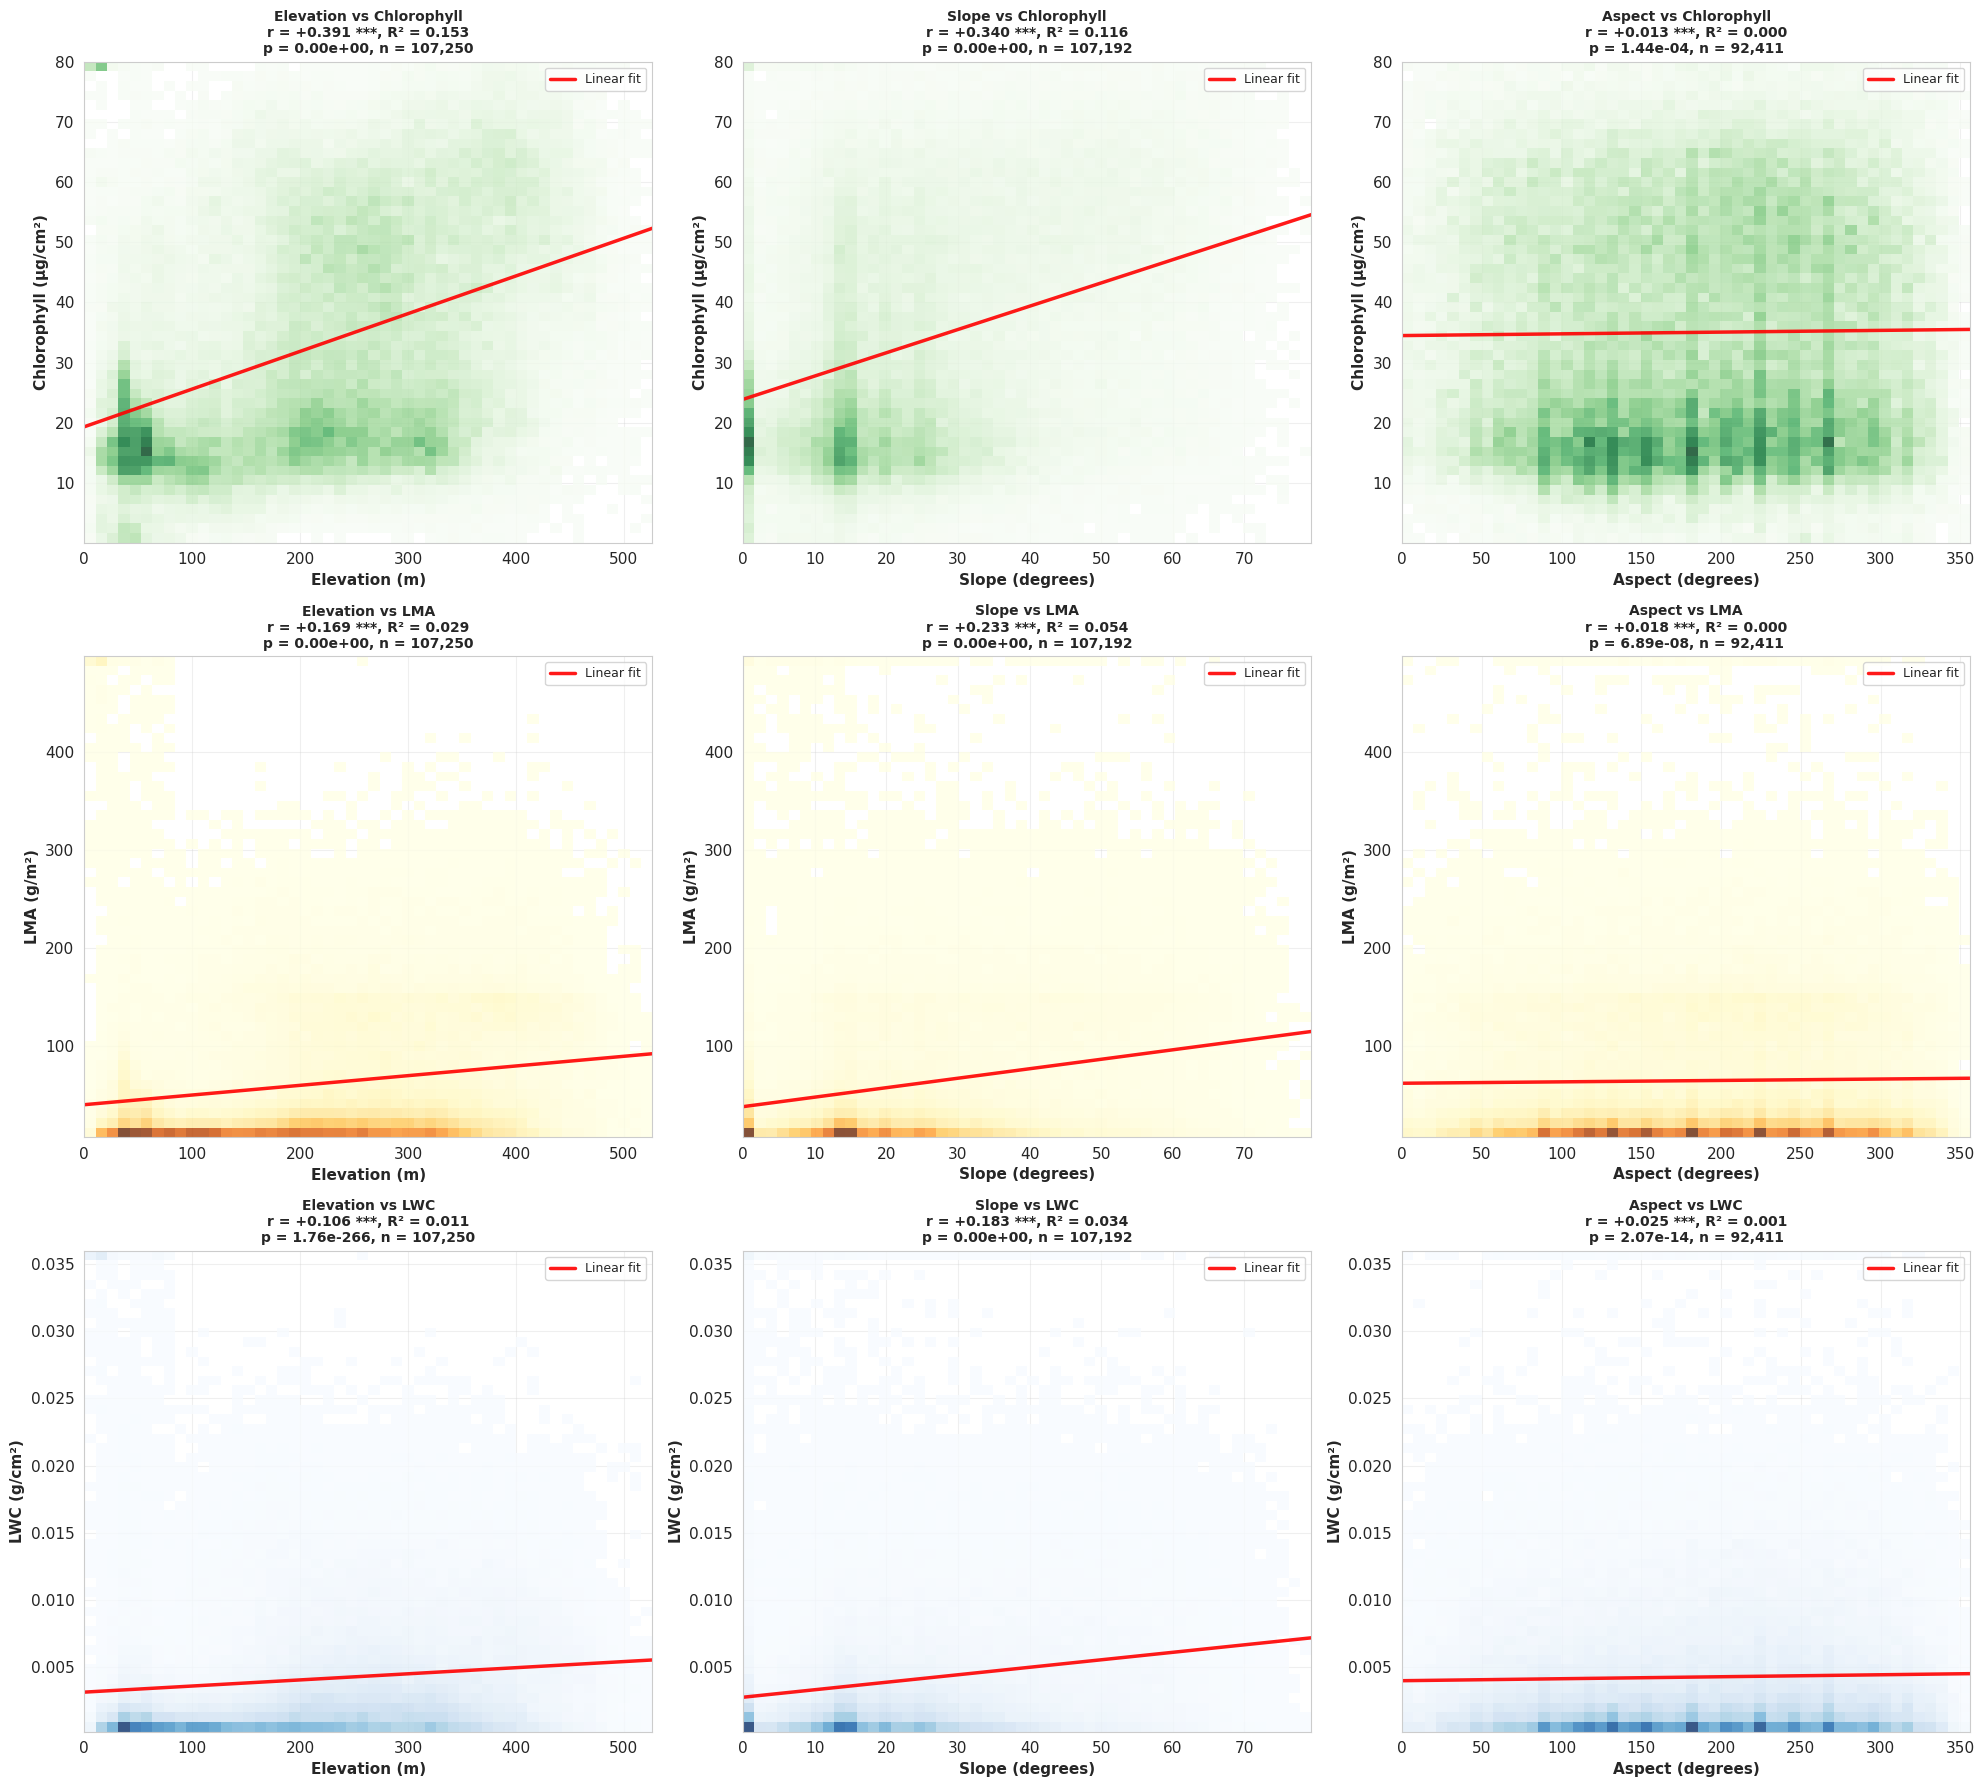

In [8]:
if topo_regridded:
    # Create 3x3 plot matrix
    fig, axes = plt.subplots(3, 3, figsize=(20, 18))
    
    # Define trait labels and colors
    trait_labels = {
        'Chlorophyll': ('Chlorophyll (μg/cm²)', 'Greens'),
        'LMA': ('LMA (g/m²)', 'YlOrBr'),
        'LWC': ('LWC (g/cm²)', 'Blues')
    }
    
    topo_labels = {
        'elevation': 'Elevation (m)',
        'slope': 'Slope (degrees)',
        'aspect': 'Aspect (degrees)'
    }
    
    # Plot each combination
    for i, (topo_name, topo_dict) in enumerate(correlation_data.items()):
        for j, (trait_name, (topo_vals, trait_vals, results)) in enumerate(topo_dict.items()):
            ax = axes[j, i]
            
            # 2D histogram for better visualization
            h = ax.hist2d(topo_vals, trait_vals, bins=50, 
                         cmap=trait_labels[trait_name][1], cmin=1, alpha=0.8)
            
            # Add regression line
            z = np.polyfit(topo_vals, trait_vals, 1)
            p = np.poly1d(z)
            x_line = np.array([topo_vals.min(), topo_vals.max()])
            ax.plot(x_line, p(x_line), "r-", linewidth=2.5, label='Linear fit', alpha=0.9)
            
            # Labels
            ax.set_xlabel(topo_labels[topo_name], fontsize=11, fontweight='bold')
            ax.set_ylabel(trait_labels[trait_name][0], fontsize=11, fontweight='bold')
            
            # Title with statistics
            sig = "***" if results['pearson_p'] < 0.001 else "**" if results['pearson_p'] < 0.01 else "*" if results['pearson_p'] < 0.05 else "ns"
            ax.set_title(
                f"{topo_name.capitalize()} vs {trait_name}\n" +
                f"r = {results['pearson_r']:+.3f} {sig}, R² = {results['r_squared']:.3f}\n" +
                f"p = {results['pearson_p']:.2e}, n = {results['n_pixels']:,}",
                fontsize=10, fontweight='bold'
            )
            
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', fontsize=9)
    
    plt.tight_layout()
    
    # Save figure
    fig_dir = elev_dir / 'figures'
    fig_dir.mkdir(exist_ok=True)
    fig_file = fig_dir / 'topography_vs_traits_comprehensive.png'
    plt.savefig(fig_file, dpi=300, bbox_inches='tight')
    print(f"✓ Comprehensive correlation figure saved to: {fig_file}")
    plt.show()
else:
    print("⚠️  Visualization skipped - no topographic data loaded")

## 6. Spatial Distribution Maps

Show spatial patterns of topographic variables and traits.

✓ Spatial distribution figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/elevation/figures/topography_and_traits_spatial.png

Coordinate info:
  Latitude:  34.4413° (south) to 34.5776° (north)
  Longitude: -120.5019° (west) to -120.3555° (east)
  Note: lat array goes south→north (increasing), lon goes west→east (increasing)


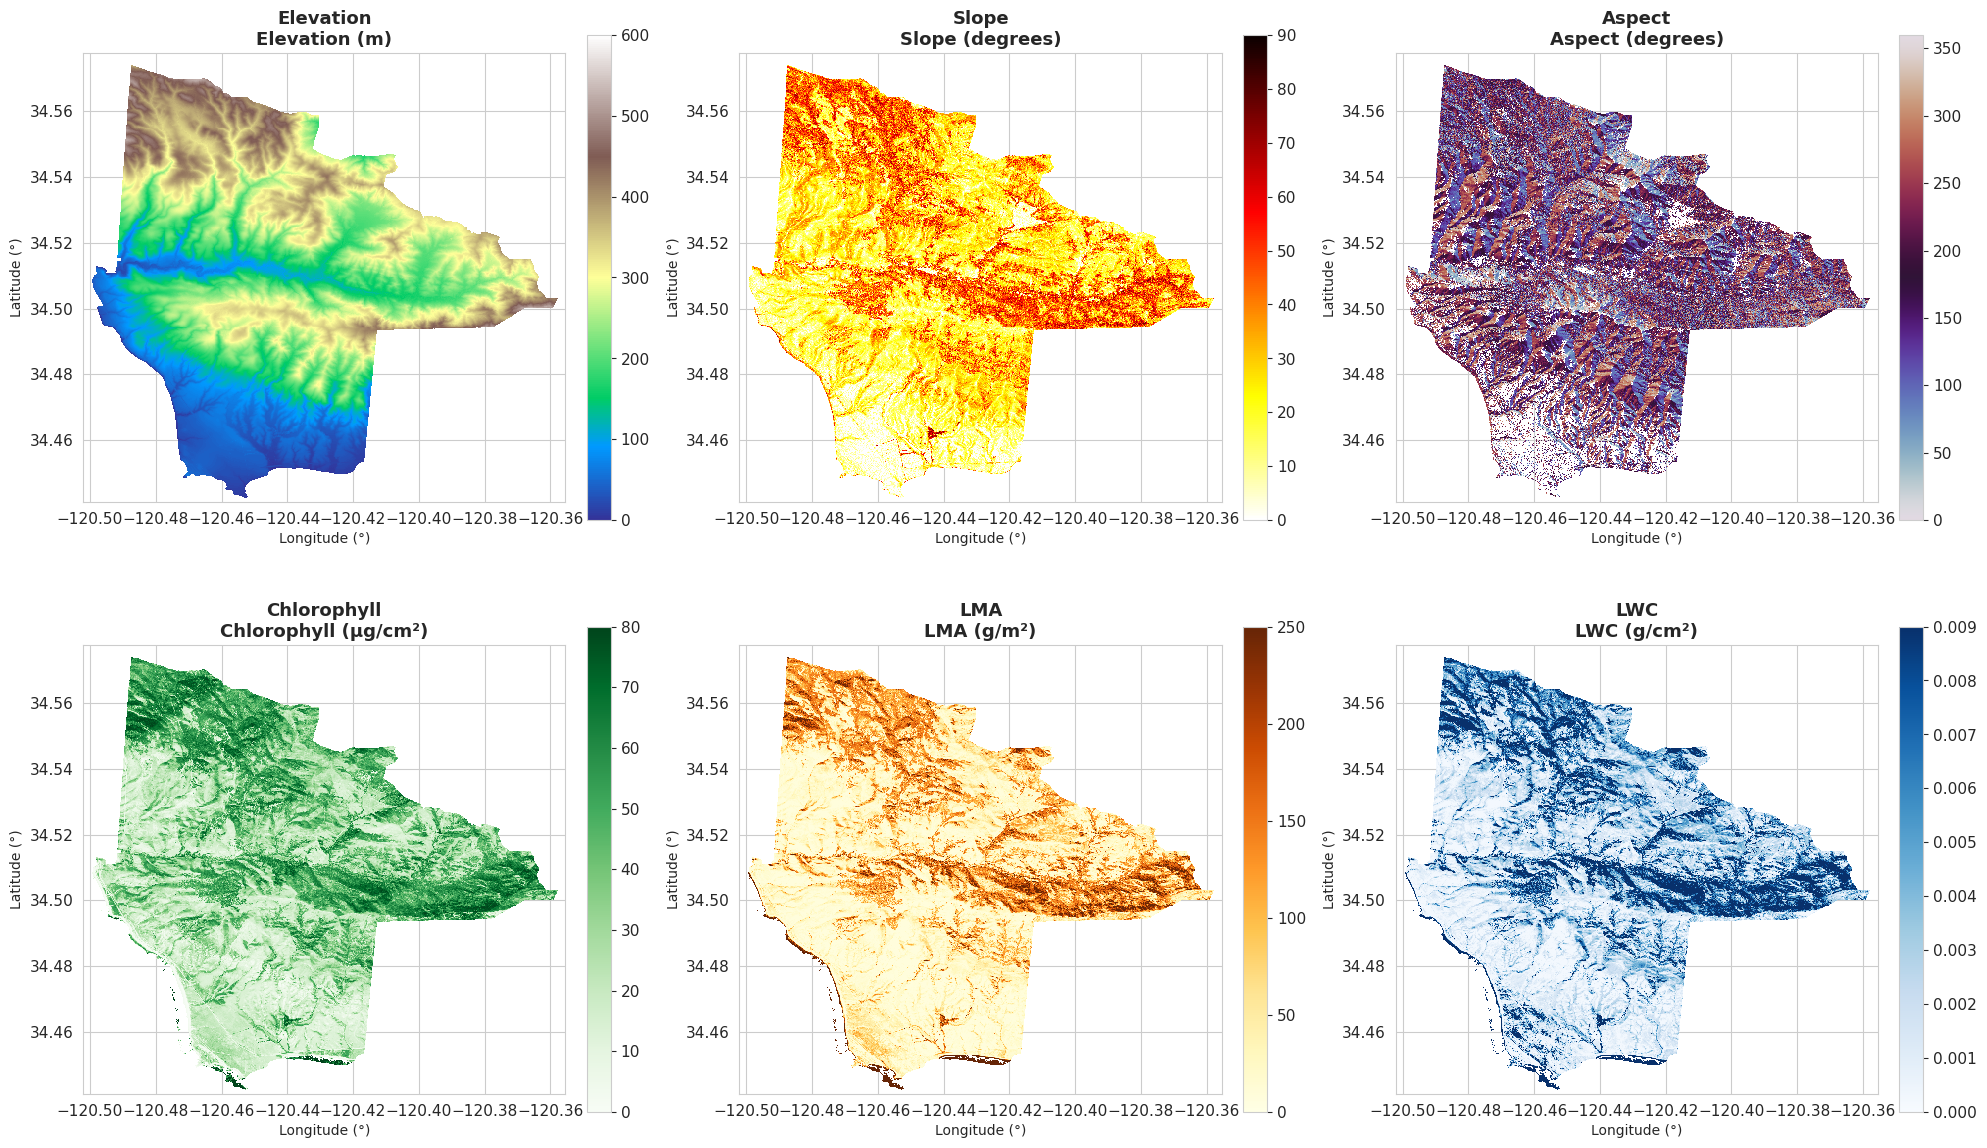

In [17]:
if topo_regridded:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Use 1D lon/lat arrays and make sure data are ordered (lat, lon) for plotting
    lon = chl_mean.lon.values
    lat = chl_mean.lat.values
    
    # Top row: Topographic variables
    for i, (topo_name, topo_var) in enumerate(topo_regridded.items()):
        ax = axes[0, i]
        
        # Properly mask the data before plotting
        data_plot = topo_var.transpose('lat', 'lon').values
        # Mask extreme values and NoData
        data_plot[(data_plot > 1e10) | (data_plot < -1000)] = np.nan
        
        if topo_name == 'elevation':
            cmap = 'terrain'
            vmin, vmax = 0, 600  # Reasonable elevation range
        elif topo_name == 'slope':
            cmap = 'hot_r'
            vmin, vmax = 0, 90  # Slope in degrees
        else:  # aspect
            cmap = 'twilight'
            vmin, vmax = 0, 360  # Aspect in degrees
        
        # Use pcolormesh like figure 6 notebooks
        im = ax.pcolormesh(lon, lat, data_plot, cmap=cmap,
                          vmin=vmin, vmax=vmax, shading='auto', rasterized=True)
        ax.set_title(f"{topo_name.capitalize()}\n{topo_labels[topo_name]}", 
                    fontsize=13, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlabel('Longitude (°)', fontsize=10)
        ax.set_ylabel('Latitude (°)', fontsize=10)
        ax.set_aspect('equal')
    
    # Bottom row: Traits
    trait_vars = [chl_mean, lma_mean, lwc_mean]
    trait_names_list = ['Chlorophyll', 'LMA', 'LWC']
    
    for i, (trait_var, trait_name) in enumerate(zip(trait_vars, trait_names_list)):
        ax = axes[1, i]
        
        # Get data and mask invalid values
        data_plot = trait_var.transpose('lat', 'lon').values
        data_plot[data_plot <= 0] = np.nan  # Mask non-positive values
        
        # Set reasonable ranges for each trait
        if trait_name == 'Chlorophyll':
            vmin, vmax = 0, 80
        elif trait_name == 'LMA':
            vmin, vmax = 0, 0.025*1e4  # g/m²
        else:  # LWC
            vmin, vmax = 0, 5* 0.0018  # g/cm²
        
        # Use pcolormesh like figure 6 notebooks
        im = ax.pcolormesh(lon, lat, data_plot, cmap=trait_labels[trait_name][1],
                          vmin=vmin, vmax=vmax, shading='auto', rasterized=True)
        ax.set_title(f"{trait_name}\n{trait_labels[trait_name][0]}", 
                    fontsize=13, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlabel('Longitude (°)', fontsize=10)
        ax.set_ylabel('Latitude (°)', fontsize=10)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    
    # Save
    spatial_fig = fig_dir / 'topography_and_traits_spatial.png'
    plt.savefig(spatial_fig, dpi=300, bbox_inches='tight')
    print(f"✓ Spatial distribution figure saved to: {spatial_fig}")
    
    # Print coordinate info for verification
    print(f"\nCoordinate info:")
    print(f"  Latitude:  {float(chl_mean.lat[0]):.4f}° (south) to {float(chl_mean.lat[-1]):.4f}° (north)")
    print(f"  Longitude: {float(chl_mean.lon[0]):.4f}° (west) to {float(chl_mean.lon[-1]):.4f}° (east)")
    print(f"  Note: lat array goes south→north (increasing), lon goes west→east (increasing)")
    
    plt.show()

## 7. Summary Table and Manuscript Text

Generate formatted summary for manuscript.

In [10]:
if topo_regridded:
    print("=" * 100)
    print("CORRELATION SUMMARY FOR MANUSCRIPT")
    print("=" * 100)
    print("\nTable: Correlations between topographic variables and optimized plant traits")
    print("-" * 100)
    
    # Create formatted table
    summary_df = correlation_df[['topo_variable', 'trait', 'pearson_r', 'pearson_p', 'r_squared', 'n_pixels']].copy()
    summary_df['significance'] = summary_df['pearson_p'].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    )
    
    print(summary_df.to_string(index=False))
    print("-" * 100)
    print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
    print("\n")
    
    # Find strongest correlations
    strongest = summary_df.loc[summary_df['r_squared'].idxmax()]
    print(f"Strongest correlation: {strongest['topo_variable']} vs {strongest['trait']}")
    print(f"  r = {strongest['pearson_r']:.3f}, R² = {strongest['r_squared']:.3f}, p = {strongest['pearson_p']:.2e}")
    
    # Count significant correlations
    n_sig = (summary_df['pearson_p'] < 0.05).sum()
    print(f"\nSignificant correlations (p < 0.05): {n_sig} out of {len(summary_df)}")
    
    print("\n" + "=" * 100)
    print("SUGGESTED MANUSCRIPT TEXT")
    print("=" * 100)
    print("\nTo address reviewer comment L704-706 regarding environmental influences on trait")
    print("variability, we examined correlations between topographic variables (elevation,")
    print("slope, aspect) and optimized plant traits (chlorophyll, LMA, LWC) across the")
    print("Dangermond Preserve.")
    print("\n[INSERT SPECIFIC RESULTS - Examples below:]")
    print("\nElevation showed significant correlations with [trait names] (r = X.XX, p < 0.001),")
    print("explaining X% of observed variance (R² = 0.XX). Similarly, slope correlated with")
    print("[trait names], while aspect showed [weak/moderate/strong] relationships with [traits].")
    print("\nThese results suggest that topography-related environmental gradients—including")
    print("temperature, solar exposure, water availability, and soil properties—contribute to")
    print("trait variation beyond PFT classification alone.")
    print("\n" + "=" * 100)
else:
    print("⚠️  Summary skipped - no results available")

CORRELATION SUMMARY FOR MANUSCRIPT

Table: Correlations between topographic variables and optimized plant traits
----------------------------------------------------------------------------------------------------
topo_variable       trait  pearson_r     pearson_p  r_squared  n_pixels significance
    Elevation Chlorophyll   0.391331  0.000000e+00   0.153140    107250          ***
    Elevation         LMA   0.169094  0.000000e+00   0.028593    107250          ***
    Elevation         LWC   0.106193 1.756863e-266   0.011277    107250          ***
        Slope Chlorophyll   0.340156  0.000000e+00   0.115706    107192          ***
        Slope         LMA   0.233085  0.000000e+00   0.054329    107192          ***
        Slope         LWC   0.183246  0.000000e+00   0.033579    107192          ***
       Aspect Chlorophyll   0.012505  1.438439e-04   0.000156     92411          ***
       Aspect         LMA   0.017743  6.892006e-08   0.000315     92411          ***
       Aspect        

## 8. Export Results

Save formatted results for easy reference.

In [11]:
if topo_regridded:
    # Create comprehensive summary file
    summary_file = elev_dir / 'analysis_summary.txt'
    
    with open(summary_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("TOPOGRAPHY vs. TRAITS CORRELATION ANALYSIS SUMMARY\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Study Area: Dangermond Preserve, California\n")
        f.write(f"Grid Size: {len(chl_mean.lat)} x {len(chl_mean.lon)} pixels\n")
        f.write(f"Topographic Variables: {', '.join(topo_regridded.keys())}\n")
        f.write(f"Plant Traits: Chlorophyll, LMA, LWC\n")
        f.write("\n" + "-"*80 + "\n\n")
        
        f.write(summary_df.to_string(index=False))
        f.write("\n\n" + "-"*80 + "\n")
        f.write("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant\n")
        f.write("\n" + "="*80 + "\n")
    
    print(f"✓ Analysis summary saved to: {summary_file}")
    print(f"✓ CSV results saved to: topography_trait_correlations.csv")
    print(f"✓ Figures saved to: figures/")
    print("\n✅ Analysis complete! All results are ready for your manuscript.")
else:
    print("⚠️  Export skipped - no results to save")

✓ Analysis summary saved to: /home/renatob/data/FluoData1/aviris_dangermond/elevation/analysis_summary.txt
✓ CSV results saved to: topography_trait_correlations.csv
✓ Figures saved to: figures/

✅ Analysis complete! All results are ready for your manuscript.
